In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('cleaned_dataset2.csv')

In [3]:
df

,Label,0,1,2,3,4,5,6,7,8,...,774,775,776,777,778,779,780,781,782,783
0,1,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255
1,0,255,255,255,255,255,254,253,252,251,...,135,190,230,255,253,253,253,254,253,252
2,3,255,255,255,255,255,255,255,253,250,...,255,255,255,255,255,255,253,248,251,255
3,9,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255
4,8,255,255,255,255,255,255,255,255,255,...,158,185,220,255,254,254,254,254,254,255
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,6,164,200,252,254,255,255,255,255,255,...,11,15,22,81,147,221,251,255,255,255
686,1,255,255,255,255,255,255,255,255,255,...,0,0,123,255,255,255,255,255,255,255
687,8,255,255,255,255,255,255,255,255,255,...,234,211,190,182,184,197,218,240,255,255
688,4,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255


In [4]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [6]:
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

feature_columns = [str(i) for i in range(784)]
X = df[feature_columns].to_numpy().astype(np.int64)
Y = df['Label'].to_numpy().astype(np.int64)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.long).to(device)

train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# print(train_dataset.tensors)
# print(test_dataset.tensors)

# print(X_test_tensor, Y_test_tensor)


In [56]:
class NeuralNet(torch.nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet, self).__init__()
        self.fc1 = torch.nn.Linear(input_size, hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size, hidden_size)
        self.fc3 = torch.nn.Linear(hidden_size, num_classes)


    def forward(self, x): 
        out = torch.relu(self.fc1(x))
        out = torch.relu(self.fc2(out))
        out = self.fc3(out)
        return out

In [57]:
model = NeuralNet(input_size=784, hidden_size=128, num_classes=10).to(device)

loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [67]:
epochs = 130

loss_list = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch_idx, (data, targets) in enumerate(train_loader):
        data = data.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(data)

        loss = loss_function(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_list.append(avg_loss)

    print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}')

Epoch [1/130], Loss: 0.0005
Epoch [2/130], Loss: 0.0005
Epoch [3/130], Loss: 0.0005
Epoch [4/130], Loss: 0.0005
Epoch [5/130], Loss: 0.0005
Epoch [6/130], Loss: 0.0005
Epoch [7/130], Loss: 0.0005
Epoch [8/130], Loss: 0.0005
Epoch [9/130], Loss: 0.0005
Epoch [10/130], Loss: 0.0005
Epoch [11/130], Loss: 0.0004
Epoch [12/130], Loss: 0.0005
Epoch [13/130], Loss: 0.0004
Epoch [14/130], Loss: 0.0004
Epoch [15/130], Loss: 0.0004
Epoch [16/130], Loss: 0.0004
Epoch [17/130], Loss: 0.0004
Epoch [18/130], Loss: 0.0004
Epoch [19/130], Loss: 0.0004
Epoch [20/130], Loss: 0.0004
Epoch [21/130], Loss: 0.0004
Epoch [22/130], Loss: 0.0004
Epoch [23/130], Loss: 0.0004
Epoch [24/130], Loss: 0.0004
Epoch [25/130], Loss: 0.0004
Epoch [26/130], Loss: 0.0004
Epoch [27/130], Loss: 0.0004
Epoch [28/130], Loss: 0.0004
Epoch [29/130], Loss: 0.0004
Epoch [30/130], Loss: 0.0004
Epoch [31/130], Loss: 0.0004
Epoch [32/130], Loss: 0.0004
Epoch [33/130], Loss: 0.0004
Epoch [34/130], Loss: 0.0004
Epoch [35/130], Loss: 0

In [68]:
model.eval()

with torch.no_grad():
    correct = 0
    total = 0
    for data, targets in test_loader:
        data = data.to(device)
        targets = targets.to(device)

        outputs = model(data)
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy of the model on the test set: {accuracy:.2f}%')


Accuracy of the model on the test set: 98.55%


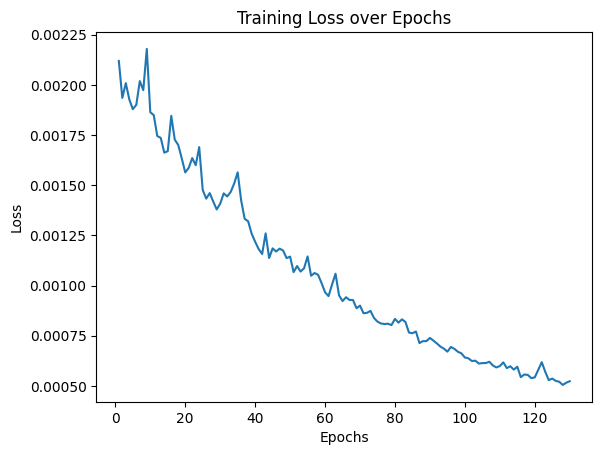

In [64]:
import matplotlib.pyplot as plt

plt.plot(range(1, epochs + 1), loss_list)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.show()

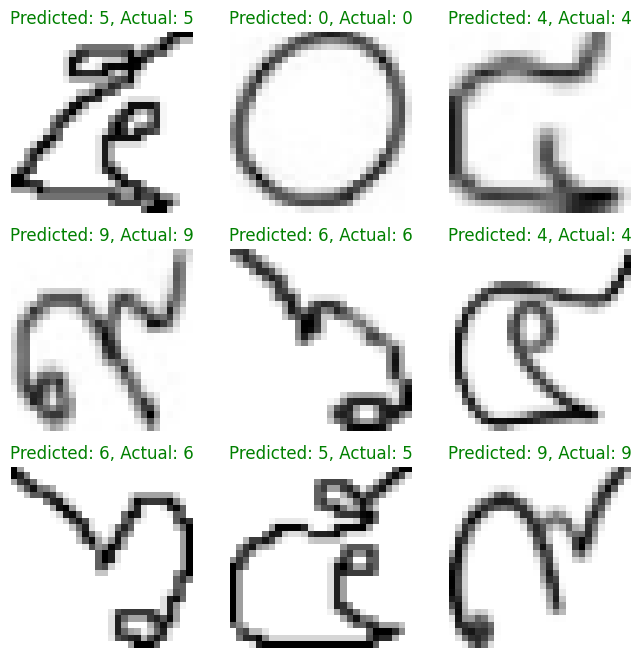

In [66]:


plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    image = X_test[i].reshape(28, 28)
    plt.imshow(image, cmap='gray')
    with torch.no_grad():
        input_tensor = torch.tensor(X_test[i], dtype=torch.float32).unsqueeze(0).to(device)
        output = model(input_tensor)
        _, predicted_label = torch.max(output.data, 1)

    if predicted_label.item() == Y_test[i]: 
        plt.title(f'Predicted: {predicted_label.item()}, Actual: {Y_test[i]}', color='green')
    else:
        plt.title(f'Predicted: {predicted_label.item()}, Actual: {Y_test[i]}', color='red')
    plt.axis('off')
plt.show()